In [1]:
# 0) ambiente y seeds
#pip install -U "transformers>=4.44" "datasets>=2.19" "accelerate>=0.34" peft bitsandbytes trl
import os, random, math, torch, pandas as pd
SEED = 123
random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.6.0+cu124 | device: cuda


In [2]:
# 1) carga tokenizer + modelo Qwen3-1.7B en 4-bit (sin LoRA aún)
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen3-1.7B"   # base para SFT
bf16_ok = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8

quant_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if bf16_ok else torch.float16,
)

print("[1] cargando tokenizer…")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, trust_remote_code=True)

print("[1] cargando modelo (4-bit)…")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, device_map="auto", quantization_config=quant_4bit, trust_remote_code=True
)

MODEL_MAX = getattr(model.config, "max_position_embeddings", 32768)  # Qwen3: 32K
tokenizer.model_max_length = MODEL_MAX
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Para entrenar en 6 GB, usamos longitud menor (2K–4K). Para inferencia podrás usar mucho más.
MAX_SEQ_LEN_TRAIN = 2048
print("[1] MODEL_MAX:", MODEL_MAX, "| MAX_SEQ_LEN_TRAIN:", MAX_SEQ_LEN_TRAIN)


[1] cargando tokenizer…
[1] cargando modelo (4-bit)…


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[1] MODEL_MAX: 40960 | MAX_SEQ_LEN_TRAIN: 2048


In [3]:
# 2) preparar k-bit + checkpointing + grads en input (aún sin LoRA)
from peft import prepare_model_for_kbit_training

print("[2] preparando para k-bit training…")
model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_enable()
model.config.use_cache = False
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()
print("[2] listo.")

[2] preparando para k-bit training…
[2] listo.


In [4]:
# 3) detectar módulos de atención y aplicar LoRA
from peft import LoraConfig, get_peft_model

# Intento directo para Qwen/LLaMA:
default_targets = ["q_proj","k_proj","v_proj","o_proj"]

# Autodetección por sufijo (por si el checkpoint cambia nombres)
all_module_names = [n for n, _ in model.named_modules()]
selected = [t for t in default_targets if any(n.endswith(t) for n in all_module_names)]
if not selected:
    # fallback: prueba otras variantes comunes
    for group in (["query_key_value","dense"], ["Wqkv","Wo"]):
        found = [t for t in group if any(n.endswith(t) for n in all_module_names)]
        if found:
            selected = found; break
if not selected:
    raise ValueError("[3] No encontré módulos de atención típicos. Ejemplos:", all_module_names[:40])

print("[3] target_modules LoRA:", selected)
lora_cfg = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias="none",
    task_type="CAUSAL_LM", target_modules=selected
)
model = get_peft_model(model, lora_cfg)

# Chequeo: % de parámetros entrenables
def count_trainable_params(m):
    tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    tot= sum(p.numel() for p in m.parameters())
    return tr, tot, 100*tr/tot
t, T, pct = count_trainable_params(model)
print(f"[3] trainables: {t:,} / {T:,} ({pct:.4f}%)")


[3] target_modules LoRA: ['q_proj', 'k_proj', 'v_proj', 'o_proj']
[3] trainables: 3,211,264 / 1,019,143,168 (0.3151%)


In [5]:
# 4) datos (CSV) y vistazo rápido
from pathlib import Path
# Ruta base
DATA_DIR = Path("data-sources/pre-processed")

# Archivos individuales
train_path = DATA_DIR / "data_finetuning_train.csv"
val_path   = DATA_DIR / "data_finetuning_val.csv"
test_path  = DATA_DIR / "data_finetuning_test.csv"
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

print(f"Train set: {len(train_df)} muestras")
print(f"Validation set: {len(val_df)} muestras")
print(f"Test set: {len(test_df)} muestras")

print("Columnas:", train_df.columns.tolist())
display(train_df.head(2))

Train set: 3038 muestras
Validation set: 380 muestras
Test set: 380 muestras
Columnas: ['name', 'article', 'summary']


,name,article,summary
0,10.1002-14651858.CD010557.pub2,Background\r\nAlthough antidepressants are oft...,Are there effective medications for treating d...
1,10.1002-14651858.CD000938.pub2,Background\r\nWomen with a suspected large‐for...,Induction of labour at or near the end of preg...


In [6]:
# 5) tokenización — sin-chunk o con-chunk
USE_CHUNKING = True  # usar chunks
MAX_TARGET_TOKENS = 384

SYS_PROMPT = (
  "You are a helpful medical/health writer who rewrites complex biomedical text into Plain Language Summaries "
  "understandable for laypeople. Use short sentences, everyday words, and neutral tone. Avoid jargon; when unavoidable, define it simply."
)

if USE_CHUNKING:
    # ---- CHUNKING (recomendado si artículos son muy largos) ----
    OVERLAP = 128
    PROMPT_PREFIX = SYS_PROMPT + "\n\nScientific Text:\n"
    PROMPT_SUFFIX = "\n\nPlain Language Summary:"

    def tokenize_chunks(article: str, summary: str):
        tgt_ids = tokenizer(summary + tokenizer.eos_token, add_special_tokens=False,
                            truncation=True, max_length=MAX_TARGET_TOKENS).input_ids
        prefix_ids = tokenizer(PROMPT_PREFIX, add_special_tokens=False).input_ids
        suffix_ids = tokenizer(PROMPT_SUFFIX, add_special_tokens=False).input_ids
        avail_for_chunk = MAX_SEQ_LEN_TRAIN - len(tgt_ids) - len(prefix_ids) - len(suffix_ids)
        if avail_for_chunk <= 0:
            ids = tgt_ids[-MAX_SEQ_LEN_TRAIN:]; labels = ids[:]
            return [{"input_ids": ids, "labels": labels}]
        art_ids = tokenizer(article, add_special_tokens=False).input_ids
        stride = max(1, avail_for_chunk - OVERLAP)
        examples = []
        for start in range(0, len(art_ids), stride):
            chunk = art_ids[start:start + avail_for_chunk]
            if not chunk: break
            inp_ids = prefix_ids + chunk + suffix_ids
            ids = inp_ids + tgt_ids
            labels = [-100]*len(inp_ids) + tgt_ids
            examples.append({"input_ids": ids, "labels": labels})
        return examples

    def df_to_dataset(frame: pd.DataFrame):
        from datasets import Dataset
        input_ids_list, labels_list = [], []
        for a, s in zip(frame["article"].tolist(), frame["summary"].tolist()):
            for ex in tokenize_chunks(a, s):
                input_ids_list.append(ex["input_ids"])
                labels_list.append(ex["labels"])
        return Dataset.from_dict({"input_ids": input_ids_list, "labels": labels_list})

else:
    # ---- SIN CHUNK (simple truncado a 4K) ----
    def build_prompt(article: str) -> str:
        return f"{SYS_PROMPT}\n\nScientific Text:\n{article}\n\nPlain Language Summary:"

    def tokenize_one(article: str, summary: str):
        tgt = tokenizer(summary + tokenizer.eos_token, add_special_tokens=False,
                        truncation=True, max_length=MAX_TARGET_TOKENS).input_ids
        avail = MAX_SEQ_LEN_TRAIN - len(tgt)
        if avail <= 0:
            ids = tgt[-MAX_SEQ_LEN_TRAIN:]; labels = ids[:]
            return {"input_ids": ids, "labels": labels}
        inp = tokenizer(build_prompt(article), add_special_tokens=False,
                        truncation=True, max_length=avail).input_ids
        ids = inp + tgt
        labels = [-100]*len(inp) + tgt
        return {"input_ids": ids, "labels": labels}

    def df_to_dataset(frame: pd.DataFrame):
        from datasets import Dataset
        input_ids_list, labels_list = [], []
        for a, s in zip(frame["article"].tolist(), frame["summary"].tolist()):
            ex = tokenize_one(a, s)
            input_ids_list.append(ex["input_ids"])
            labels_list.append(ex["labels"])
        return Dataset.from_dict({"input_ids": input_ids_list, "labels": labels_list})

print("[5] tokenizador listo. USE_CHUNKING =", USE_CHUNKING)


[5] tokenizador listo. USE_CHUNKING = True


In [7]:
# 6) split y construcción de datasets tokenizados
from datasets import DatasetDict

print("[6] tokenizando train…")
tok_train = df_to_dataset(train_df)
print("[6] tokenizando val…")
tok_val   = df_to_dataset(val_df)
print("[6] tokenizando test…")
tok_test  = df_to_dataset(test_df)

tok = DatasetDict(train=tok_train, validation=tok_val, test=tok_test)
print(tok)


[6] tokenizando train…
[6] tokenizando val…
[6] tokenizando test…
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 3594
    })
    validation: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 455
    })
    test: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 443
    })
})


In [8]:
# 7) collator + sanity forward
from dataclasses import dataclass
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

@dataclass
class CausalCollator:
    pad_token_id: int
    def __call__(self, batch):
        ii = [torch.tensor(b["input_ids"], dtype=torch.long) for b in batch]
        ll = [torch.tensor(b["labels"],    dtype=torch.long) for b in batch]
        am = [torch.ones_like(x) for x in ii]
        ii = pad_sequence(ii, batch_first=True, padding_value=self.pad_token_id)
        ll = pad_sequence(ll, batch_first=True, padding_value=-100)
        am = pad_sequence(am, batch_first=True, padding_value=0)
        return {"input_ids": ii, "labels": ll, "attention_mask": am}

collator = CausalCollator(pad_token_id=tokenizer.pad_token_id)
dl = DataLoader(tok["train"], batch_size=1, shuffle=True, collate_fn=collator)

batch = next(iter(dl))
for k,v in batch.items(): print("[7]", k, v.shape, v.dtype)

model.train()
with torch.cuda.amp.autocast(dtype=torch.bfloat16 if bf16_ok else torch.float16):
    out = model(**{k: v.to(model.device) for k,v in batch.items()})
print("[7] loss forward ok:", float(out.loss))



[7] input_ids torch.Size([1, 2048]) torch.int64
[7] labels torch.Size([1, 2048]) torch.int64
[7] attention_mask torch.Size([1, 2048]) torch.int64


C:\Users\jsoa\AppData\Local\Temp\ipykernel_16380\3890302759.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.bfloat16 if bf16_ok else torch.float16):


[7] loss forward ok: 2.3968825340270996


In [9]:
# 8) sanity backward (un paso manual)
optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=2e-4)
batch = next(iter(dl))
batch = {k: v.to(model.device) for k,v in batch.items()}
optim.zero_grad()
with torch.cuda.amp.autocast(dtype=torch.bfloat16 if bf16_ok else torch.float16):
    out = model(**batch)
loss = out.loss
print("[8] loss:", float(loss), "| requires_grad:", loss.requires_grad)
loss.backward()
optim.step()
print("[8] backward y step OK")

C:\Users\jsoa\AppData\Local\Temp\ipykernel_16380\91581523.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.bfloat16 if bf16_ok else torch.float16):


[8] loss: 2.3402469158172607 | requires_grad: True
[8] backward y step OK


In [10]:
# 9) Trainer (1 época para validación de pipeline)
from transformers import Trainer, TrainingArguments

EPOCHS = 1
BATCH_SIZE = 1
ACCUM_STEPS = 16
WARMUP_RATIO = 0.1

n_train = len(tok["train"])
steps_per_epoch = 30
warmup_steps = int(WARMUP_RATIO * steps_per_epoch * EPOCHS)

args = TrainingArguments(
    output_dir="outputs/qwen3-1p7b-qlora",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=ACCUM_STEPS,
    num_train_epochs=EPOCHS,
    learning_rate=2e-4,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,
    logging_steps=steps_per_epoch,
    do_eval=True,
    eval_strategy="steps",
    eval_steps=steps_per_epoch,
    save_steps=steps_per_epoch,
    save_total_limit=2,
    bf16=bf16_ok,
    fp16=not bf16_ok,
    dataloader_pin_memory=True,
    seed=SEED, data_seed=SEED,
    report_to=None,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tok["train"],
    eval_dataset=tok["validation"],
    data_collator=collator,
)


print(f"[9] entrenando… pasos/época={steps_per_epoch}")
trainer.train()
print("[9] fin de trainer.train()")


[9] entrenando… pasos/época=30


wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\jsoa\_netrc
wandb: Currently logged in as: jsoa9012 (jsoa9012-universidad-de-los-andes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss
30,1.774300,1.628680
60,1.614600,1.580671
90,1.588200,1.561297
120,1.575000,1.550925
150,1.561400,1.544420
180,1.553100,1.541577
210,1.555800,1.540492


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7859f29a-c613-4a71-97b8-1c123bfe3f14)')' thrown while requesting HEAD https://huggingface.co/Qwen/Qwen3-1.7B/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: fce17a17-ca9f-48c7-9dcc-de2ef5a0955e)')' thrown while requesting HEAD https://huggingface.co/Qwen/Qwen3-1.7B/resolve/main/config.json
Retrying in 1s [Retry 1/5].


[9] fin de trainer.train()


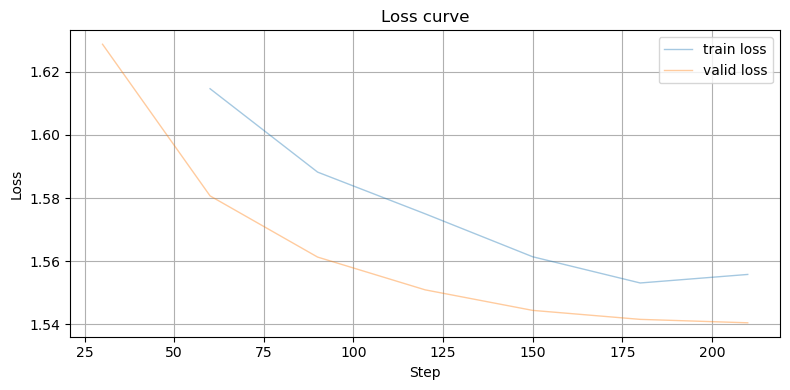

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


logs = pd.DataFrame(trainer.state.log_history)

train = logs.loc[logs["loss"].notna(), ["step", "loss"]]
valid = logs.loc[logs["eval_loss"].notna(), ["step", "eval_loss"]]

plt.figure(figsize=(8,4))
plt.plot(train["step"][1:], train["loss"][1:], label="train loss", linewidth=1, alpha=0.4)
plt.plot(valid["step"], valid["eval_loss"], label="valid loss", linewidth=1, alpha=0.4)
plt.xlabel("Step");
plt.ylabel("Loss");
plt.title("Loss curve");
plt.legend();
plt.grid(True)
plt.tight_layout();
plt.show()


In [14]:
#  10) Guardar modelo
# Guarda los pesos finales del modelo ajustado
trainer.save_model("models/qwen3-1p7b")

# Guarda el tokenizer para inferencia
tokenizer.save_pretrained("models/qwen3-1p7b")

('models/qwen3-1p7b\\tokenizer_config.json',
 'models/qwen3-1p7b\\special_tokens_map.json',
 'models/qwen3-1p7b\\chat_template.jinja',
 'models/qwen3-1p7b\\vocab.json',
 'models/qwen3-1p7b\\merges.txt',
 'models/qwen3-1p7b\\added_tokens.json',
 'models/qwen3-1p7b\\tokenizer.json')

In [ ]:
# # 10) Evaluar modelo
trainer.evaluate()

In [ ]:
# 11) Cargar modelo
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch

# === Configura rutas ===
MODEL_ID = "models/qwen3-1p7b-qlora"
CKPT_DIR = "outputs/qwen3-1p7b-qlora/checkpoint-225"   # tu checkpoint entrenado

# === Carga tokenizer ===
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# === Carga modelo base en 4bit ===
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.float16
)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, device_map="auto", quantization_config=bnb_cfg, trust_remote_code=True
)

# === Monta el adaptador LoRA fine-tuneado ===
model = PeftModel.from_pretrained(base_model, CKPT_DIR)
model.eval()

print("✅ Modelo y adaptador cargados correctamente")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Modelo y adaptador cargados correctamente


C:\Users\jsoa\AppData\Roaming\Python\Python312\site-packages\peft\tuners\tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
# ============================
# Generar PLS con Qwen (HF) usando columnas: name, article, summary
# ============================

import re
from pathlib import Path
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm

# ---- 2) Prompt
def generar_prompt(cientific_text):
    input_text = f"""You are a helpful medical/health writer.
Summarize the following scientific text into a clear summary intented for a general audience.
Do NOT use headings, titles, bullet points, or numbered lists. Do not invent data or references.
If you must use a technical term, briefly define it.

Cientific Text: {cientific_text}

PLS Text:"""
    return input_text

@torch.inference_mode()
def generate_pls_batch(
    data: str,
    prompt_fn,
    batch_size: int = 2,
    max_new_tokens: int = 380,     # suficiente para 4–6 oraciones
    temperature: float = 0.0,      # determinista → mejor factualidad
    top_p: float = 1.0,
    num_beams: int = 1,
    repetition_penalty: float = 1.02,
    no_repeat_ngram_size: int = 4,
):
    texts = data['article'].fillna("").astype(str).tolist()
    df_out = data.copy()

    # Calcula un input máximo seguro
    max_ctx = getattr(model.config, "max_position_embeddings", 4096)
    max_input_len = max(8, max_ctx - max_new_tokens)

    outputs = []
    pbar = tqdm(total=len(texts), desc='Generando resúmenes', unit="sample")

    try:
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            prompts = [prompt_fn(t) for t in batch_texts]

            enc = tokenizer(
                prompts,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_input_len,
            )
            input_ids = enc["input_ids"].to(model.device)
            attention_mask = enc["attention_mask"].to(model.device)

            gen_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=(temperature > 0.0 or top_p < 1.0),
                temperature=temperature,
                top_p=top_p,
                num_beams=num_beams,
                no_repeat_ngram_size=no_repeat_ngram_size,
                repetition_penalty=repetition_penalty,
                use_cache=True,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
            )

            # Cortar por muestra usando la longitud REAL (no el ancho padded)
            batch_out = []
            input_lens = attention_mask.sum(dim=1)  # [B]
            for row in range(input_ids.size(0)):
                ilen = int(input_lens[row].item())
                gen_only = gen_ids[row, ilen:]        # ← clave: corta desde fin del prompt de ESA fila
                text = tokenizer.decode(gen_only, skip_special_tokens=True).strip()
                batch_out.append(text)

            outputs.extend(batch_out)
            pbar.update(len(batch_texts))
    finally:
        pbar.close()

    df_out['gen_summary'] = outputs
    return df_out

# O el CoT factual corto
def generar_prompt(cientific_text):
    input_text = f"""You are a helpful medical/health writer.
Summarize the following scientific text into a clear summary intented for a general audience.
Do NOT use headings, titles, bullet points, or numbered lists. Do not invent data or references.
If you must use a technical term, briefly define it.

Cientific Text: {cientific_text}

PLS Text:"""
    return input_text

DATA_DIR = Path("data-sources/pre-processed")
RESULTS_DIR = Path("models/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df_test = pd.read_csv(DATA_DIR / "data_finetuning_test.csv")

df_output = generate_pls_batch(
    data=df_test,
    prompt_fn=generar_prompt,   # o prompt_sencillo
    batch_size=4,
    max_new_tokens=380,
    temperature=0.0,
    top_p=1.0,
)
RESULTS_DIR = Path("models/results")

csv_out = RESULTS_DIR / "summaries_qwen3.csv"
df_output.to_csv(csv_out, index=False, encoding="utf-8")
print(f"Guardado CSV con PLS: {csv_out}")


`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/190 [00:00<?, ?it/s]

Guardado CSV con PLS: models\results\qwen3\train_with_pls.csv
Archivos .txt guardados en: C:\Users\jsoa\Documents\GitHub\Proyecto-PLN-FLAG\src\models\results\qwen3


In [ ]:
# ============================
# Generar PLS con Qwen (HF) usando columnas: name, article, summary
# ============================

import re
import time  # NEW
from pathlib import Path
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm

@torch.inference_mode()
def generate_pls_batch(
    data: str,
    prompt_fn,
    batch_size: int = 2,
    max_new_tokens: int = 380,     # suficiente para 4–6 oraciones
    temperature: float = 0.0,      # determinista → mejor factualidad
    top_p: float = 1.0,
    num_beams: int = 1,
    repetition_penalty: float = 1.02,
    no_repeat_ngram_size: int = 4,
):
    texts = data['article'].fillna("").astype(str).tolist()
    df_out = data.copy()

    # Calcula un input máximo seguro
    max_ctx = getattr(model.config, "max_position_embeddings", 4096)
    max_input_len = max(8, max_ctx - max_new_tokens)

    outputs = []
    latencies = []  # NEW
    pbar = tqdm(total=len(texts), desc='Generando resúmenes', unit="sample")

    try:
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            prompts = [prompt_fn(t) for t in batch_texts]

            enc = tokenizer(
                prompts,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_input_len,
            )
            input_ids = enc["input_ids"].to(model.device)
            attention_mask = enc["attention_mask"].to(model.device)

            # --- NEW: medir tiempo del batch con sync de GPU
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.perf_counter()

            gen_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=(temperature > 0.0 or top_p < 1.0),
                temperature=temperature,
                top_p=top_p,
                num_beams=num_beams,
                no_repeat_ngram_size=no_repeat_ngram_size,
                repetition_penalty=repetition_penalty,
                use_cache=True,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
            )

            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            per_item_latency = (t1 - t0)  # NEW

            # Cortar por muestra usando la longitud REAL (no el ancho padded)
            batch_out = []
            input_lens = attention_mask.sum(dim=1)  # [B]
            for row in range(input_ids.size(0)):
                ilen = int(input_lens[row].item())
                gen_only = gen_ids[row, ilen:]        # ← clave: corta desde fin del prompt de ESA fila
                text = tokenizer.decode(gen_only, skip_special_tokens=True).strip()
                batch_out.append(text)

            outputs.extend(batch_out)
            latencies.extend([per_item_latency] * len(batch_texts))  # NEW
            pbar.update(len(batch_texts))
    finally:
        pbar.close()

    df_out['gen_summary'] = outputs
    df_out['latency_s'] = latencies  # NEW
    return df_out

# O el CoT factual corto
def generar_prompt(cientific_text):
    input_text = f"""You are a helpful medical/health writer.
Summarize the following scientific text into a clear summary intented for a general audience.
Do NOT use headings, titles, bullet points, or numbered lists. Do not invent data or references.
If you must use a technical term, briefly define it.

Cientific Text: {cientific_text}

PLS Text:"""
    return input_text

DATA_DIR = Path("data-sources/pre-processed")
RESULTS_DIR = Path("models/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df_test = pd.read_csv(DATA_DIR / "data_finetuning_test.csv")
df_output = generate_pls_batch(
    data=df_test,
    prompt_fn=generar_prompt,   # o prompt_sencillo
    batch_size=5,
    max_new_tokens=380,
    temperature=0.0,
    top_p=1.0,
)

csv_out = RESULTS_DIR / "summaries_qwen3.csv"
df_output.to_csv(csv_out, index=False, encoding="utf-8")
print(f"Guardado CSV con PLS: {csv_out}")
print("Latencia promedio (s):", df_output["latency_s"].mean())


Generando resúmenes:   0%|          | 0/380 [00:00<?, ?sample/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tok

Guardado CSV con PLS: models\results\summaries_qwen3.csv
Latencia promedio (s): 39.75669932236748
